In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import geopandas as gpd
import pandas as pd
import os
from tile import tile_sampler

In [3]:
os.getcwd()
os.chdir(r'c:\\Users\\solan\\OneDrive\\Desktop\\IntrotoPython\\FinalProj\\cropfield-polygonization\\data')

zambia_shp = gpd.read_parquet(r'zambia_2023_attributed.parquet')

This file demonstrates and tests the `poly.py` `polysplitter` function and shows the development of this function. First we start by examining a `test_tile` provided by Gregg Essuman. We are looking at both the tile in its entirety and also spatial outliers in this tile in `test_tile_filt` - that is, the least compact, highest shape index, highest interior edge, ad highest fractal dimensionality polygons. Compactness, or circularity, defines how “round” a cropfield polygon is, where low values indicate that a polygon is elongated. Shape index is the inverse square of compactness, where high values indicate that a polygon is elongated, and should be more sensitive to highly irregular shapes. Interior edge is the ratio of perimeter to area. Fractal dimension is another way to measure irregularity, where values close to 2 represent irregular shapes and values close to 1 represent very round, regular shapes.

The original test tile is a good, representative sample of many different polygon types in the Zambia cropfield dataset. The filtered dataset allows us to more quickly see how this function performs on the "worst" polygons in the dataset. 

In [4]:
# test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)
test_tile = zambia_shp[zambia_shp['tile_id'] == 883180]

# Look at the bottom 25% compactness, top 25% shape index, top 25% interior edge, top 25% fractal dim
test_tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]

test_tile_filt = test_tile_filt.to_crs(32735)
test_tile_filt.describe()

print(test_tile_filt.crs)

EPSG:32735


The function is defined as shown below. See `poly.py` for function as well. This function only splits a polygon a single time. See `thinnecks.ipynb` and `poly_recursive.py` for details on the recursive version of this function. 

In [5]:
from shapely.ops import split
from shapely.geometry import Point
from shapely.ops import nearest_points
from shapely import LineString
import pandas as pd
from shapely.ops import unary_union
from shapely.affinity import scale
from numpy import sqrt
from shapely.ops import snap

def poly_splitter(gdf, perimeter_column, geometry_column, delta):
    """
        This function splits a polygon at the narrowest point determined using a negative buffer. 

        Arguments: 
        gdf : Geodataframe
        perimeter_column : Name of column with perimeter values
        delta: buffer step (should be positive)

        Required packages: Shapely, pandas
        
        Other relevant packages: geopandas (geodataframe creation and loading), os (directory navigation)
    """

    gdf = gdf.copy()
    gdf['sdist'] = None
    gdf['buffers_geom'] = None
    gdf['buffer_geom1'] = None
    gdf['buffer_geom2'] = None
    gdf['pinch1'] = None
    gdf['pinch2'] = None
    gdf['line'] = None
    gdf['cut_geom1'] = None
    gdf['cut_geom2'] = None

    
    for idx, row in gdf.iterrows():
        max_len = gdf.at[idx, perimeter_column]
        current_buff = 0
        while current_buff <= max_len:
            current_buff += delta
            buffered = row[geometry_column].buffer(-current_buff)
            if buffered.geom_type == 'MultiPolygon' and current_buff > 0.2:
                geoms = list(buffered.geoms)
                print(f"Split at row {idx}, buffer distance {current_buff:.3f}")

                gdf.at[idx, 'buffers_geom'] = buffered
                gdf.at[idx, 'sdist'] = -current_buff 
                gdf.at[idx, 'buffer_geom1'] = geoms[0]
                gdf.at[idx, 'buffer_geom2'] = geoms[1]
                break
        else:
            print(f"No split for row {idx} within max_len={max_len}")

    # Connecting narrowest part
    for idx, row in gdf.iterrows():
        if pd.isna(row['sdist']):
            continue
        else:
            p1, p2 = nearest_points(row['buffer_geom1'], row['buffer_geom2'])
            gdf.at[idx, 'pinch1'] = p1
            gdf.at[idx, 'pinch2'] = p2
            gdf.at[idx, 'line'] = LineString([p1, p2])

    # Creating Cut Line (Perpendicular Line) and cutting
    for idx, row in gdf.iterrows():
        if pd.isna(row['sdist']):
            continue
        else: 
            bounds = gdf.at[idx, geometry_column].bounds
            dist = max(bounds[2] - bounds[0], bounds[3] - bounds[1])/4

            point1 = gdf.at[idx, 'pinch1']
            point2 = gdf.at[idx, 'pinch2']

            dx = point1.x - point2.x
            dy = point1.y - point2.y
            length = sqrt(dx**2 + dy**2)
            perp_dx = -dy / length  # perpendicular unit vector
            perp_dy = dx / length   

            midpoint = Point((point1.x + point2.x) / 2, (point1.y + point2.y) / 2)
            perp_line = LineString([(midpoint.x - dist * perp_dx, midpoint.y - perp_dy * dist ), (midpoint.x + dist * perp_dx, midpoint.y + perp_dy * dist)])

            snapped_line = snap(perp_line, gdf.at[idx, geometry_column], tolerance=1.0) 
            cut = split(gdf.at[idx, geometry_column], snapped_line)

            if len(cut.geoms) == 1: #"failed" cut
                gdf.at[idx, 'sdist'] = None 
                gdf.at[idx, 'cut_geom1'] = None
                gdf.at[idx, 'cut_geom2'] = None

            if len(cut.geoms) == 2:
                sorted_geoms = sorted(cut.geoms, key=lambda g: g.area, reverse=True)
                gdf.at[idx, 'cut_geom1'] = sorted_geoms[0]
                gdf.at[idx, 'cut_geom2'] = sorted_geoms[1]
                
            elif len(cut.geoms) > 2: # need to account for extra accidental splits for areas near the split line
                sorted_geoms = sorted(cut.geoms, key=lambda g: g.area, reverse=True)
                big1, big2 = sorted_geoms[0], sorted_geoms[1]
                slivers = sorted_geoms[2:]  # everything after the top 2
                merge_with_1 = [big1]
                merge_with_2 = [big2]
        
                for sliver in slivers:
                    sharededge1 = big1.intersection(sliver).length # shared edge between sliver and "majority" p9ieces
                    sharededge2 = big2.intersection(sliver).length

                    overlap = big2.intersection(sliver)
                    
                    if sharededge1 == sharededge2: # if same distance from both (usually split at a point), go with closer piece
                        if big1.distance(sliver) <= big2.distance(sliver):  
                            merge_with_1.append(sliver)
                        else:
                            merge_with_2.append(sliver)
                    elif sharededge1 >= sharededge2:
                        merge_with_1.append(sliver)
                    else:
                        merge_with_2.append(sliver)
                gdf.at[idx, 'cut_geom1'] = unary_union(merge_with_1)
                gdf.at[idx, 'cut_geom2'] = unary_union(merge_with_2)

    return gdf


To demonstrate how this function behaves, we can test it on a sample polygon identified in ArcGISPro:

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1 entries, 8104591 to 8104591
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        1 non-null      float64 
 1   area_ha        1 non-null      float64 
 2   perimeter_m    1 non-null      float64 
 3   compactness    1 non-null      float64 
 4   shape_index    1 non-null      float64 
 5   interior_edge  1 non-null      float64 
 6   fractal_dim    1 non-null      float64 
 7   tile_id        1 non-null      float64 
 8   polygon_index  1 non-null      float64 
 9   polygon_id     1 non-null      float64 
 10  geometry       1 non-null      geometry
dtypes: float64(10), geometry(1)
memory usage: 96.0 bytes


<Axes: >

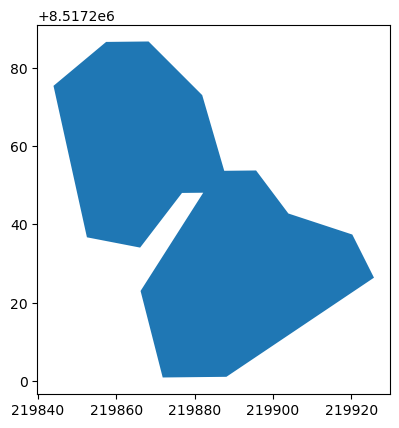

In [6]:
from shapely.geometry import Point

# Test poly (1)
point = Point(24.4135987, -13.3993874)  

# Select the polygon that contains the point
test_poly = test_tile[test_tile.geometry.contains(point)]
test_poly = test_poly.to_crs(32735)

test_poly.info()

test_poly.plot()

This is a sample run outside of the defined function so that each negative buffer geometry can be collected and plotted. The chunk below shows how the buffer step `delta` is used to shift the perimeter a fixed distance inward while the total buffer distance is less than a max length parameter, defined by the perimeter of the polygon. The for loop stops at the point the polygon defined by the bounds of the buffer splits, or becomes a Multipolygon. The reasoning behind this is that if a section of a polygon is thinner than the rest, it will split into a Multipolygon at this location first.

Split happened at buffer distance 4.0.


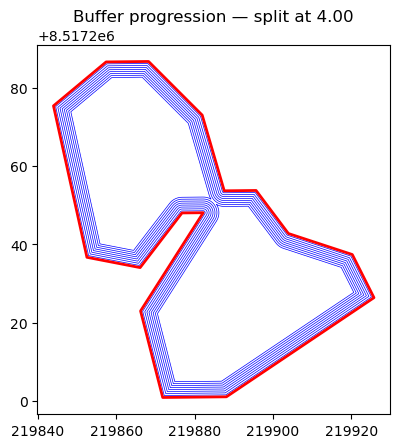

In [7]:
import matplotlib.pyplot as plt 
import matplotlib.cm as cm 

fig, ax = plt.subplots()

delta = .5 # buffer step
max_len = test_poly['perimeter_m'].iloc[0] 

idx = test_poly.index[0]

buffers = []
current_buff = 0

while current_buff <= max_len:
    current_buff += delta
    buffered = test_poly['geometry'].iloc[0].buffer(-current_buff)
    buffers.append(buffered)
    if buffered.geom_type == 'MultiPolygon':
        geoms = list(buffered.geoms)
        print(f"Split happened at buffer distance {current_buff}.")
        test_poly.loc[idx, 'geometry_test'] = buffered # buffer geometry
        test_poly.loc[idx, 'sdist'] = -current_buff #buffer 
        test_poly.loc[idx, 'buffer_geom1'] = geoms[0] # geometry 1 for split poly
        test_poly.loc[idx, 'buffer_geom2'] = geoms[1] # geometry 2 for split poly
        break
else:
    print(f"No split within dimension limit")


for geom in buffers: 
    gpd.GeoSeries([geom]).plot(ax = ax, facecolor = 'none', edgecolor = 'blue', linewidth = 0.5)

test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
plt.title(f"Buffer progression — split at {current_buff:.2f}")
plt.show()

The Multipolygons created at the split can be plotted as well: 

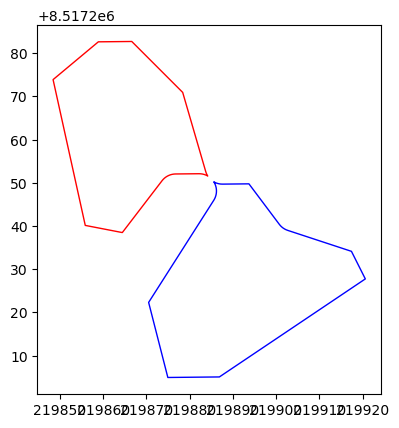

In [8]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
plt.show()

Under the assumption that the closest points on the Multipolygons will be where the split happened, we can collect these points and create a line connecting these points. Using this line, a midpoint can be generated and then a perpendicular line can be drawn and extended that will cross the exterior boundaries of the original polygon. The chunk below generates plots for the multipolygons and the original polygon, the connecting line and the perpendicular cut line, and the cut line overlaid over the original polygon and the buffer multipolygons for illustrative purposes.

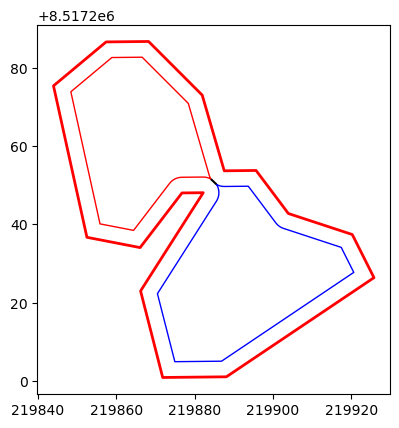

c:\Users\solan\anaconda3\envs\arcgispro-gpd\Lib\site-packages\shapely\geometry\linestring.py:67: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return [float(c) for c in o]


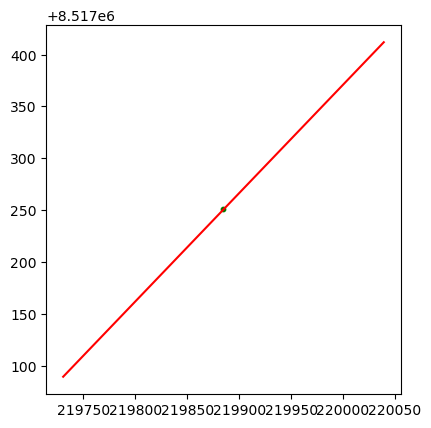

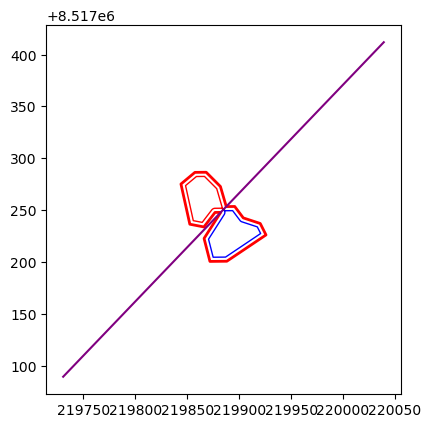

In [9]:
# NEAREST POINTS TEST

from shapely.ops import nearest_points
from shapely import ops 
from shapely import LineString


p1, p2 = nearest_points(test_poly['buffer_geom1'].iloc[0], test_poly['buffer_geom2'].iloc[0])
test_poly.at[idx, 'pinch1'] = p1
test_poly.at[idx, 'pinch2'] = p2
test_poly.at[idx, 'line'] = LineString([p1, p2]) # line connecting closest points

# Goal is to create perpendicular line to split the original polygon
 
fig, ax = plt.subplots()
test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
plt.show()

# Finding perpendicular line to connecting line
line = gpd.GeoDataFrame(geometry = test_poly['line']) # original polygon line

dist = (test_poly['geometry'].length)/2 # larger dist here than in function just to exaggerate it fo rplotting purposes 

point1 = test_poly['pinch1'].iloc[0]
point2 = test_poly['pinch2'].iloc[0]

dx = point1.x - point2.x
dy = point1.y - point2.y
 
midpoint = Point(
    (point1.x + point2.x) / 2,
    (point1.y + point2.y) / 2
)

perp_slope = -(dx/dy)

perp_line = LineString([(midpoint.x - dist, midpoint.y - perp_slope * dist), (midpoint.x + dist, midpoint.y + perp_slope * dist)])

fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
gpd.GeoSeries(perp_line).plot(ax=ax, color = 'red')
gpd.GeoSeries([midpoint]).plot(ax=ax, color = 'green', markersize = 10)
plt.show()

fig, ax = plt.subplots()
test_poly.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2, label='Original')
gpd.GeoSeries(test_poly['buffer_geom1']).plot(ax=ax, edgecolor='red', facecolor='none')
gpd.GeoSeries(test_poly['buffer_geom2']).plot(ax=ax, edgecolor='blue', facecolor='none')
gpd.GeoSeries(test_poly['line']).plot(ax = ax, edgecolor = 'black')
gpd.GeoSeries(perp_line).plot(ax=ax, color = 'purple')
plt.show()

Now we can split our original polygon and plot the resulting pieces whose geometries are captured under `cut_geom1` and `cut_geom2`.

<Axes: >

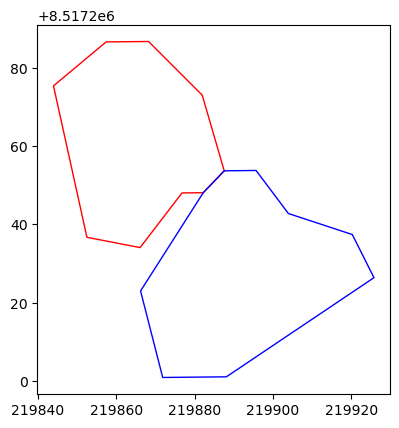

In [10]:
gpd.GeoSeries(perp_line)
from shapely.ops import split

cut = split(test_poly['geometry'].iloc[0], perp_line)

test_poly['cut_geom1'] = cut.geoms[0]
test_poly['cut_geom2'] = cut.geoms[1]

fig, ax = plt.subplots()
gpd.GeoSeries(test_poly['cut_geom1']).plot(ax = ax, facecolor = 'none', edgecolor = 'red')
gpd.GeoSeries(test_poly['cut_geom2']).plot(ax = ax, facecolor = 'none', edgecolor = 'blue')

That works on a small scale - what about a larger dataset, like `test_tile_filt`?

In [11]:
test_tile_filt.info()

test_tile_filt_res = poly_splitter(test_tile_filt, 'perimeter_m', 'geometry', 0.1)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41 entries, 8104396 to 8106014
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   area_m2        41 non-null     float64 
 1   area_ha        41 non-null     float64 
 2   perimeter_m    41 non-null     float64 
 3   compactness    41 non-null     float64 
 4   shape_index    41 non-null     float64 
 5   interior_edge  41 non-null     float64 
 6   fractal_dim    41 non-null     float64 
 7   tile_id        41 non-null     float64 
 8   polygon_index  41 non-null     float64 
 9   polygon_id     41 non-null     float64 
 10  geometry       41 non-null     geometry
dtypes: float64(10), geometry(1)
memory usage: 3.8 KB
Split at row 8104396, buffer distance 5.200
Split at row 8104405, buffer distance 5.300
Split at row 8104443, buffer distance 4.100
Split at row 8104482, buffer distance 1.900
Split at row 8104492, buffer distance 4.800
Split at row 8104495, bu

To plot the split polygons, we can plot the geometries from `cut_geom1` and `cut_geom2`. 

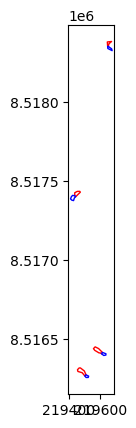

In [12]:
fig, ax = plt.subplots()
gpd.GeoSeries(test_tile_filt_res.dropna(subset=['cut_geom1'])['cut_geom1']).head(4).plot(ax=ax, facecolor='none', edgecolor='red')
gpd.GeoSeries(test_tile_filt_res.dropna(subset=['cut_geom2'])['cut_geom2']).head(4).plot(ax=ax, facecolor='none', edgecolor='blue')
plt.show()